In [ ]:
# ============================================================
#  MST BiLSTM on PAMAP2 dataset

# ============================================================
import os
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, confusion_matrix, classification_report)

# ---------------------------
# Settings
# ---------------------------
DATA_PATH = "PAMAP2_Dataset"   # adjust if needed
SEQ_LEN = 100
STRIDE = 20
MAX_WORKERS = 0                # dataloader workers (set >0 if you want)
BATCH_SIZE = 64
EPOCHS = 20
LR = 1e-3
MIXUP_ALPHA = 0.4

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------------------------
# 1) Load + Preprocess (your Window 1 code, slightly compacted)
# ---------------------------
def load_pamap2_data(data_path=DATA_PATH):
    print("Loading PAMAP2 dataset from:", data_path)
    all_data = []
    all_labels = []

    # column names as you used (excluding orientation later)
    column_names = ['timestamp','activity_id','heart_rate']
    imu_columns = [
        'temperature','acceleration_16g_x','acceleration_16g_y','acceleration_16g_z',
        'acceleration_6g_x','acceleration_6g_y','acceleration_6g_z',
        'gyroscope_x','gyroscope_y','gyroscope_z',
        'magnetometer_x','magnetometer_y','magnetometer_z',
        'orientation_1','orientation_2','orientation_3','orientation_4'
    ]
    for pos in ['hand','chest','ankle']:
        for c in imu_columns:
            column_names.append(f"{pos}_{c}")

    # Protocol
    protocol_path = os.path.join(data_path, "Protocol")
    if os.path.exists(protocol_path):
        for f in os.listdir(protocol_path):
            if f.endswith('.dat'):
                fp = os.path.join(protocol_path, f)
                try:
                    df = pd.read_csv(fp, sep=' ', header=None, names=column_names)
                    df = df[df['activity_id'] != 0]
                    orientation_cols = [c for c in df.columns if 'orientation' in c]
                    df = df.drop(columns=orientation_cols)
                    feature_cols = [c for c in df.columns if c not in ['timestamp','activity_id']]
                    all_data.append(df[feature_cols])
                    all_labels.append(df['activity_id'])
                except Exception as e:
                    print("Error loading", fp, e)

    # Optional
    optional_path = os.path.join(data_path, "Optional")
    if os.path.exists(optional_path):
        for f in os.listdir(optional_path):
            if f.endswith('.dat'):
                fp = os.path.join(optional_path, f)
                try:
                    df = pd.read_csv(fp, sep=' ', header=None, names=column_names)
                    df = df[df['activity_id'] != 0]
                    orientation_cols = [c for c in df.columns if 'orientation' in c]
                    df = df.drop(columns=orientation_cols)
                    feature_cols = [c for c in df.columns if c not in ['timestamp','activity_id']]
                    all_data.append(df[feature_cols])
                    all_labels.append(df['activity_id'])
                except Exception as e:
                    print("Error loading", fp, e)

    if not all_data:
        raise FileNotFoundError("No PAMAP2 .dat files found in Protocol/Optional folders.")

    X = pd.concat(all_data, ignore_index=True)
    y = pd.concat(all_labels, ignore_index=True)
    print("Loaded:", X.shape, "labels:", y.shape)
    return X, y

def create_sequences(X, y, seq_len=SEQ_LEN, stride=STRIDE):
    X_seq, y_seq = [], []
    for i in range(0, len(X) - seq_len, stride):
        X_seq.append(X[i:i+seq_len])
        lab = y[i:i+seq_len]
        # majority label in the window
        most_common = np.argmax(np.bincount(lab))
        y_seq.append(most_common)
    X_seq = np.array(X_seq, dtype=np.float32)
    y_seq = np.array(y_seq, dtype=np.int64)
    return X_seq, y_seq

print("1) Loading and preprocessing...")
X_df, y_ser = load_pamap2_data(DATA_PATH)

# Basic cleaning
X_df = X_df.fillna(X_df.mean())
# drop constant cols
const_cols = X_df.columns[X_df.nunique() <= 1]
if len(const_cols) > 0:
    print("Dropping constant cols:", list(const_cols))
    X_df = X_df.drop(columns=const_cols)

X = X_df.values.astype(np.float32)
y = y_ser.values

le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)
n_classes = len(class_names)
print("Mapped activities -> classes:", n_classes)

# scale
scaler = StandardScaler()
X = scaler.fit_transform(X)
print("Features scaled")

# create sequences
X_seq, y_seq = create_sequences(X, y_enc, seq_len=SEQ_LEN, stride=STRIDE)
print("Sequences:", X_seq.shape, "Labels:", np.bincount(y_seq))

# splits
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X_seq, y_seq, test_size=0.3, stratify=y_seq, random_state=42)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=42)
print("Splits -> train:", X_tr.shape, "val:", X_val.shape, "test:", X_te.shape)

# ---------------------------
# PyTorch Dataset + Loaders
# ---------------------------
class SeqDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = torch.utils.data.DataLoader(SeqDataset(X_tr, y_tr), batch_size=BATCH_SIZE,
                                           shuffle=True, num_workers=MAX_WORKERS, pin_memory=True)
val_loader = torch.utils.data.DataLoader(SeqDataset(X_val, y_val), batch_size=BATCH_SIZE,
                                         shuffle=False, num_workers=MAX_WORKERS, pin_memory=True)
test_loader = torch.utils.data.DataLoader(SeqDataset(X_te, y_te), batch_size=BATCH_SIZE,
                                          shuffle=False, num_workers=MAX_WORKERS, pin_memory=True)

# ---------------------------
# 2) Mixup utilities
# ---------------------------
def mixup_data(x, y, alpha=MIXUP_ALPHA):
    if alpha <= 0:
        return x, y, None, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0))
    mixed_x = lam * x + (1 - lam) * x[idx].to(x.device)
    y_a, y_b = y, y[idx].to(y.device)
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# ---------------------------
# 3) Model components (MST_Full)
# ---------------------------
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=8):
        super().__init__()
        r = max(1, channel // reduction)
        self.fc1 = nn.Linear(channel, r)
        self.fc2 = nn.Linear(r, channel)
    def forward(self, x):
        # x: (B, C, T)
        w = x.mean(dim=2)             # (B, C)
        w = F.relu(self.fc1(w))
        w = torch.sigmoid(self.fc2(w)).unsqueeze(2)  # (B, C, 1)
        return x * w

class MST_Full(nn.Module):
    def __init__(self, input_dim, seq_len, num_classes,
                 cnn_channels=64, hidden_dim=64, lstm_layers=1, dropout=0.3, num_heads=4):
        super().__init__()
        # CNN stack
        self.conv1 = nn.Conv1d(in_channels=input_dim, out_channels=cnn_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(cnn_channels)
        self.conv2 = nn.Conv1d(in_channels=cnn_channels, out_channels=cnn_channels//2, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(cnn_channels//2)
        self.relu = nn.ReLU()

        # SE on CNN channels
        self.se = SEBlock(cnn_channels//2, reduction=8)

        # BiLSTM on raw features
        self.bilstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim,
                              num_layers=lstm_layers, batch_first=True, bidirectional=True, dropout=dropout)

        # fused dim (ensure divisible by num_heads)
        fused_dim = 2*hidden_dim + (cnn_channels//2)
        assert fused_dim % num_heads == 0, f"fusion dim {fused_dim} must be divisible by num_heads {num_heads}"

        self.gate = nn.Linear(fused_dim, fused_dim)

        # Multihead attention: we will pass sequence length =1 tokens (so batch_first True)
        self.attn = nn.MultiheadAttention(embed_dim=fused_dim, num_heads=num_heads, batch_first=True)
        self.ln = nn.LayerNorm(fused_dim)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(fused_dim, num_classes)

    def forward(self, x):
        # x: (B, T, F)
        B, T, F_in = x.shape

        # CNN path: operate on (B, F, T)
        c = x.permute(0,2,1)   # (B, F, T)
        c = self.relu(self.bn1(self.conv1(c)))
        c = self.relu(self.bn2(self.conv2(c)))
        c = self.se(c)         # (B, C', T)
        f_cnn = c.mean(dim=2)  # (B, C')

        # BiLSTM path on original inputs
        lstm_out, _ = self.bilstm(x)   # (B, T, 2H)
        f_lstm = lstm_out.mean(dim=1)  # (B, 2H)

        # concat
        f_cat = torch.cat([f_cnn, f_lstm], dim=1)  # (B, fused_dim)

        # gated fusion
        gate = torch.sigmoid(self.gate(f_cat))
        f_gate = f_cat * gate                    # (B, fused_dim)

        # multi-head temporal attention (on single token sequence)
        q = f_gate.unsqueeze(1)   # (B, 1, D)
        attn_out, _ = self.attn(q, q, q)   # (B, 1, D)
        attn_out = attn_out.squeeze(1)     # (B, D)
        attn_out = self.ln(attn_out)

        out = self.dropout(attn_out)
        logits = self.fc(out)
        return logits

# ---------------------------
# 4) Instantiate model + training utilities
# ---------------------------
input_dim = X_seq.shape[2]
num_classes = n_classes
print("Input dim:", input_dim, "Num classes:", num_classes)

# choose dims to keep fusion_dim divisible: hidden_dim=64, cnn_channels=64 -> fused_dim = 128 + 32 = 160 -> divisible by 4
model = MST_Full(input_dim=input_dim, seq_len=SEQ_LEN, num_classes=num_classes,
                 cnn_channels=64, hidden_dim=64, lstm_layers=1, dropout=0.25, num_heads=4)
model = model.to(device)
print("Model params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# ---------------------------
# 5) Train (mixup on training batches)
# ---------------------------
best_val = -1.0
best_path = "best_MST_full.pth"
train_start = time.time()
for epoch in range(1, EPOCHS+1):
    model.train()
    running_loss = 0.0
    total = 0
    correct = 0
    for Xb, yb in train_loader:
        Xb = Xb.to(device); yb = yb.to(device)
        X_mix, y_a, y_b, lam = mixup_data(Xb, yb, alpha=MIXUP_ALPHA)
        optimizer.zero_grad()
        outputs = model(X_mix)
        loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * Xb.size(0)
        preds = outputs.argmax(dim=1)
        # For mixup the accuracy reported is on mixed inputs; not strictly meaningful but okay for quick monitoring
        correct += (preds == y_a).sum().item()
        total += Xb.size(0)

    # validation
    model.eval()
    val_preds = []
    val_trues = []
    with torch.no_grad():
        for Xv, yv in val_loader:
            Xv = Xv.to(device); yv = yv.to(device)
            outv = model(Xv)
            pv = outv.argmax(dim=1)
            val_preds.extend(pv.cpu().tolist())
            val_trues.extend(yv.cpu().tolist())
    val_acc = accuracy_score(val_trues, val_preds)
    avg_loss = running_loss / max(1, total)
    print(f"Epoch {epoch}/{EPOCHS}  Loss: {avg_loss:.4f}  ValAcc: {val_acc:.4f}")
    if val_acc > best_val:
        best_val = val_acc
        torch.save(model.state_dict(), best_path)
        print("  >> saved best model")

train_time = time.time() - train_start
print("Training finished in {:.1f}s | best val {:.4f}".format(train_time, best_val))

# ---------------------------
# 6) Load best model and evaluate on test set (timing w/ CUDA sync)
# ---------------------------
if os.path.exists(best_path):
    model.load_state_dict(torch.load(best_path, map_location=device))
    print("Loaded best model:", best_path)

model.eval()
if torch.cuda.is_available(): torch.cuda.synchronize()
t0 = time.time()
preds = []
probs = []
trues = []
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device); yb = yb.to(device)
        out = model(Xb)
        p = torch.softmax(out, dim=1)
        preds.extend(out.argmax(dim=1).cpu().tolist())
        probs.extend(p.cpu().numpy().tolist())
        trues.extend(yb.cpu().tolist())
if torch.cuda.is_available(): torch.cuda.synchronize()
t1 = time.time()

total_pred_time = (t1 - t0)
per_sample_ms = (total_pred_time / len(trues)) * 1000
throughput = len(trues) / max(1e-9, total_pred_time)

preds = np.array(preds)
probs = np.array(probs)
trues = np.array(trues)

# metrics
acc = accuracy_score(trues, preds)
f1 = f1_score(trues, preds, average='weighted')
prec = precision_score(trues, preds, average='weighted', zero_division=0)
rec = recall_score(trues, preds, average='weighted', zero_division=0)
# roc auc: handle multiclass
try:
    if num_classes == 2:
        roc = roc_auc_score(trues, probs[:,1])
    else:
        # one-vs-rest macro
        from sklearn.preprocessing import label_binarize
        y_onehot = label_binarize(trues, classes=np.arange(num_classes))
        roc = roc_auc_score(y_onehot, probs, average='macro', multi_class='ovr')
except Exception:
    roc = 0.0

cm = confusion_matrix(trues, preds)
class_names = [str(c) for c in class_names]  # convert to string list

cr = classification_report(trues, preds, target_names=class_names, zero_division=0)

print("\nTest results:")
print(f"Samples: {len(trues)}  Accuracy: {acc:.4f}  F1: {f1:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  ROC_AUC: {roc:.4f}")
print(f"Prediction time total: {total_pred_time:.4f}s  per-sample: {per_sample_ms:.4f} ms  throughput: {throughput:.2f} samples/s")
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n", cr)

# ---------------------------
# 7) Save metrics and reports to Excel
# ---------------------------
xls_name = "MST_Full_PAMAP2_Results.xlsx"
summary = {
    "Accuracy": [acc],
    "F1_Score": [f1],
    "Precision": [prec],
    "Recall": [rec],
    "ROC_AUC": [roc],
    "Parameters": [sum(p.numel() for p in model.parameters() if p.requires_grad)],
    "Model_Size_MB": [round(sum(p.numel()*p.element_size() for p in model.parameters())/1024**2, 4)],
    "Training_Time_seconds": [round(train_time, 4)],
    "Prediction_Time_ms": [round(per_sample_ms, 4)],
    "Throughput_samples_sec": [round(throughput,2)],
    "Sequence_Length": [SEQ_LEN],
    "Features": [input_dim],
    "Test_Samples": [len(trues)]
}
df_sum = pd.DataFrame(summary)

with pd.ExcelWriter(xls_name, engine='openpyxl') as writer:
    df_sum.to_excel(writer, sheet_name='Summary', index=False)
    pd.DataFrame(cm).to_excel(writer, sheet_name='Confusion_Matrix', index=True, header=True)
    # classification report as dict
    try:
        cr_dict = classification_report(trues, preds, output_dict=True, zero_division=0)
        pd.DataFrame(cr_dict).transpose().to_excel(writer, sheet_name='Classification_Report')
    except Exception:
        pd.DataFrame({"report":[cr]}).to_excel(writer, sheet_name='Classification_Report', index=False)

print("Results saved to", xls_name)


Using device: cuda
1) Loading and preprocessing...
Loading PAMAP2 dataset from: PAMAP2_Dataset
Loaded: (2724953, 40) labels: (2724953,)
Mapped activities -> classes: 18
Features scaled
Sequences: (136243, 100, 40) Labels: [ 9625  9259  9495 11941  4911  8229  9404  4182 15497  2726  5862  5244
  8768 11936  4994  9359  2343  2468]
Splits -> train: (95370, 100, 40) val: (20436, 100, 40) test: (20437, 100, 40)
Input dim: 40 Num classes: 18
Model params: 200694


c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.25 and num_layers=1
  warnings.warn(


Epoch 1/20  Loss: 0.8335  ValAcc: 0.9702
  >> saved best model
Epoch 2/20  Loss: 0.7110  ValAcc: 0.9846
  >> saved best model
Epoch 3/20  Loss: 0.6760  ValAcc: 0.9880
  >> saved best model
Epoch 4/20  Loss: 0.6529  ValAcc: 0.9905
  >> saved best model
Epoch 5/20  Loss: 0.6255  ValAcc: 0.9912
  >> saved best model
Epoch 6/20  Loss: 0.6176  ValAcc: 0.9928
  >> saved best model
Epoch 7/20  Loss: 0.6092  ValAcc: 0.9936
  >> saved best model
Epoch 8/20  Loss: 0.6035  ValAcc: 0.9943
  >> saved best model
Epoch 9/20  Loss: 0.5725  ValAcc: 0.9951
  >> saved best model
Epoch 10/20  Loss: 0.5812  ValAcc: 0.9952
  >> saved best model
Epoch 11/20  Loss: 0.5604  ValAcc: 0.9949
Epoch 12/20  Loss: 0.5740  ValAcc: 0.9962
  >> saved best model
Epoch 13/20  Loss: 0.5519  ValAcc: 0.9959
Epoch 14/20  Loss: 0.5580  ValAcc: 0.9962
Epoch 15/20  Loss: 0.5550  ValAcc: 0.9964
  >> saved best model
Epoch 16/20  Loss: 0.5436  ValAcc: 0.9963
Epoch 17/20  Loss: 0.5423  ValAcc: 0.9960
Epoch 18/20  Loss: 0.5419  ValA

TypeError: object of type 'numpy.int64' has no len()

In [3]:
# ============================
# Final Evaluation + Excel Save
# ============================
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, confusion_matrix, classification_report)

model.eval()
if torch.cuda.is_available(): torch.cuda.synchronize()
t0 = time.time()

preds, probs, trues = [], [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        out = model(Xb)
        p = torch.softmax(out, dim=1)
        preds.extend(out.argmax(dim=1).cpu().tolist())
        probs.extend(p.cpu().numpy().tolist())
        trues.extend(yb.cpu().tolist())

if torch.cuda.is_available(): torch.cuda.synchronize()
t1 = time.time()

# ---------- Timing ----------
total_pred_time = t1 - t0
per_sample_ms = (total_pred_time / len(trues)) * 1000
throughput = len(trues) / max(1e-9, total_pred_time)

preds = np.array(preds)
probs = np.array(probs)
trues = np.array(trues)

# ---------- Metrics ----------
acc = accuracy_score(trues, preds)
f1 = f1_score(trues, preds, average='weighted')
prec = precision_score(trues, preds, average='weighted', zero_division=0)
rec = recall_score(trues, preds, average='weighted', zero_division=0)

try:
    if num_classes == 2:
        roc = roc_auc_score(trues, probs[:, 1])
    else:
        y_onehot = label_binarize(trues, classes=np.arange(num_classes))
        roc = roc_auc_score(y_onehot, probs, average='macro', multi_class='ovr')
except Exception:
    roc = 0.0

cm = confusion_matrix(trues, preds)
cr = classification_report(trues, preds, target_names=[str(c) for c in class_names], zero_division=0)

print("\n================ Test Results ================")
print(f"Samples: {len(trues)}")
print(f"Accuracy:  {acc:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"ROC_AUC:   {roc:.4f}")
print(f"Prediction time total: {total_pred_time:.4f}s")
print(f"Per-sample time: {per_sample_ms:.4f} ms")
print(f"Throughput: {throughput:.2f} samples/s")
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", cr)

# ---------- Save to Excel ----------
xls_name = "MST_Full_PAMAP2_Results.xlsx"
summary = {
    "Accuracy": [acc],
    "F1_Score": [f1],
    "Precision": [prec],
    "Recall": [rec],
    "ROC_AUC": [roc],
    "Parameters": [sum(p.numel() for p in model.parameters() if p.requires_grad)],
    "Model_Size_MB": [round(sum(p.numel() * p.element_size() for p in model.parameters()) / 1024**2, 4)],
    "Prediction_Time_ms": [round(per_sample_ms, 4)],
    "Throughput_samples_sec": [round(throughput, 2)],
    "Sequence_Length": [SEQ_LEN],
    "Features": [input_dim],
    "Test_Samples": [len(trues)]
}

df_sum = pd.DataFrame(summary)
with pd.ExcelWriter(xls_name, engine='openpyxl') as writer:
    df_sum.to_excel(writer, sheet_name='Summary', index=False)
    pd.DataFrame(cm).to_excel(writer, sheet_name='Confusion_Matrix', index=True, header=True)
    cr_dict = classification_report(trues, preds, output_dict=True, zero_division=0)
    pd.DataFrame(cr_dict).transpose().to_excel(writer, sheet_name='Classification_Report')

print("\n✅ Metrics and reports saved to", xls_name)



================ Test Results ================
Samples: 20437
Accuracy:  0.9970
F1-score:  0.9970
Precision: 0.9970
Recall:    0.9970
ROC_AUC:   1.0000
Prediction time total: 1.7611s
Per-sample time: 0.0862 ms
Throughput: 11604.95 samples/s

Confusion Matrix:
 [[1444    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0]
 [   0 1387    2    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0]
 [   0    6 1415    0    0    0    0    0    0    0    0    0    2    1
     0    0    0    0]
 [   0    0    0 1789    0    0    0    0    0    0    0    2    0    0
     0    0    0    0]
 [   0    0    0    0  733    1    0    0    0    0    0    0    0    0
     0    0    2    0]
 [   0    0    0    0    0 1235    0    0    0    0    0    0    0    0
     0    0    0    0]
 [   0    0    0    1    0    0 1410    0    0    0    0    0    0    0
     0    0    0    0]
 [   0    0    0    0    0    0    0  627    0    0    0    0    0    0
 

In [3]:
# =====================================
# Window 1: Data Loading and Preprocessing
# =====================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, roc_auc_score, 
                           classification_report, mean_absolute_error, 
                           mean_squared_error, r2_score, f1_score, 
                           precision_score, recall_score, accuracy_score)
import matplotlib.pyplot as plt
import seaborn as sns
import time
import psutil
import warnings
warnings.filterwarnings('ignore')

# Force CPU for stability
device = torch.device('cpu')
print("Using CPU for stability")

def load_pamap2_data(data_path="PAMAP2_Dataset"):
    print("Loading PAMAP2 dataset from local files...")
    all_data = []
    all_labels = []
    
    column_names = ['timestamp', 'activity_id', 'heart_rate']
    imu_columns = [
        'temperature', 'acceleration_16g_x', 'acceleration_16g_y', 'acceleration_16g_z',
        'acceleration_6g_x', 'acceleration_6g_y', 'acceleration_6g_z',
        'gyroscope_x', 'gyroscope_y', 'gyroscope_z',
        'magnetometer_x', 'magnetometer_y', 'magnetometer_z',
        'orientation_1', 'orientation_2', 'orientation_3', 'orientation_4'
    ]
    
    for position in ['hand', 'chest', 'ankle']:
        for col in imu_columns:
            column_names.append(f'{position}_{col}')
    
    # Load data from Protocol folder
    protocol_path = os.path.join(data_path, "Protocol")
    if os.path.exists(protocol_path):
        print("Loading Protocol data...")
        for subject_file in os.listdir(protocol_path):
            if subject_file.endswith('.dat'):
                file_path = os.path.join(protocol_path, subject_file)
                print(f"  Loading {file_path}")
                try:
                    subject_data = pd.read_csv(file_path, sep=' ', header=None, names=column_names)
                    subject_data = subject_data[subject_data['activity_id'] != 0]
                    # Remove orientation columns
                    orientation_cols = [col for col in subject_data.columns if 'orientation' in col]
                    subject_data = subject_data.drop(columns=orientation_cols)
                    feature_cols = [col for col in subject_data.columns if col not in ['timestamp', 'activity_id']]
                    all_data.append(subject_data[feature_cols])
                    all_labels.append(subject_data['activity_id'])
                except Exception as e:
                    print(f"    Error loading {file_path}: {e}")
    
    # Load data from Optional folder
    optional_path = os.path.join(data_path, "Optional")
    if os.path.exists(optional_path):
        print("Loading Optional data...")
        for subject_file in os.listdir(optional_path):
            if subject_file.endswith('.dat'):
                file_path = os.path.join(optional_path, subject_file)
                print(f"  Loading {file_path}")
                try:
                    subject_data = pd.read_csv(file_path, sep=' ', header=None, names=column_names)
                    subject_data = subject_data[subject_data['activity_id'] != 0]
                    orientation_cols = [col for col in subject_data.columns if 'orientation' in col]
                    subject_data = subject_data.drop(columns=orientation_cols)
                    feature_cols = [col for col in subject_data.columns if col not in ['timestamp', 'activity_id']]
                    all_data.append(subject_data[feature_cols])
                    all_labels.append(subject_data['activity_id'])
                except Exception as e:
                    print(f"    Error loading {file_path}: {e}")
    
    if not all_data:
        raise ValueError("No data files found in PAMAP2_Dataset folder")
    
    X = pd.concat(all_data, ignore_index=True)
    y = pd.concat(all_labels, ignore_index=True)
    
    print(f"\nLoaded dataset shape: {X.shape}")
    print(f"Target shape: {y.shape}")
    return X, y

# Load and preprocess data
X, y = load_pamap2_data("PAMAP2_Dataset")

# Preprocessing
X_clean = X.fillna(X.mean())
constant_cols = X_clean.columns[X_clean.nunique() <= 1]
if len(constant_cols) > 0:
    print(f"Removing constant columns: {list(constant_cols)}")
    X_clean = X_clean.drop(columns=constant_cols)

X_array = X_clean.values.astype(np.float32)
y_array = y.values

le = LabelEncoder()
y_encoded = le.fit_transform(y_array)
activity_mapping = {i: label for i, label in enumerate(le.classes_)}
print(f"Activity mapping: {activity_mapping}")
print(f"Final dataset shape: {X_array.shape}")
print(f"Class distribution: {np.bincount(y_encoded)}")

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_array)
print(f"Features scaled - mean: {X_scaled.mean():.3f}, std: {X_scaled.std():.3f}")

# Create sequences
def create_sequences(X, y, seq_len=100, stride=20):
    print(f"\nCreating sequences (length: {seq_len}, stride: {stride})...")
    X_seq, y_seq = [], []
    
    for i in range(0, len(X) - seq_len, stride):
        X_seq.append(X[i:i+seq_len])
        sequence_labels = y[i:i+seq_len]
        most_common_label = np.argmax(np.bincount(sequence_labels))
        y_seq.append(most_common_label)
    
    X_seq = np.array(X_seq, dtype=np.float32)
    y_seq = np.array(y_seq, dtype=np.int64)
    
    print(f"Sequences created: {X_seq.shape}")
    print(f"Sequence class distribution: {np.bincount(y_seq)}")
    return X_seq, y_seq

sequence_length = 100
stride = 20
X_seq, y_seq = create_sequences(X_scaled, y_encoded, seq_len=sequence_length, stride=stride)

# Split data
X_train, X_temp, y_train, y_temp = train_test_split(
    X_seq, y_seq, test_size=0.3, stratify=y_seq, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"\nData splits:")
print(f"Train: {X_train.shape}, classes: {np.bincount(y_train)}")
print(f"Val: {X_val.shape}, classes: {np.bincount(y_val)}")
print(f"Test: {X_test.shape}, classes: {np.bincount(y_test)}")

# Save processed data for next windows
np.save('X_train.npy', X_train)
np.save('X_val.npy', X_val)
np.save('X_test.npy', X_test)
np.save('y_train.npy', y_train)
np.save('y_val.npy', y_val)
np.save('y_test.npy', y_test)

print("\nData preprocessing completed and saved!")

Using CPU for stability
Loading PAMAP2 dataset from local files...
Loading Protocol data...
  Loading PAMAP2_Dataset\Protocol\subject101.dat
  Loading PAMAP2_Dataset\Protocol\subject102.dat
  Loading PAMAP2_Dataset\Protocol\subject103.dat
  Loading PAMAP2_Dataset\Protocol\subject104.dat
  Loading PAMAP2_Dataset\Protocol\subject105.dat
  Loading PAMAP2_Dataset\Protocol\subject106.dat
  Loading PAMAP2_Dataset\Protocol\subject107.dat
  Loading PAMAP2_Dataset\Protocol\subject108.dat
  Loading PAMAP2_Dataset\Protocol\subject109.dat
Loading Optional data...
  Loading PAMAP2_Dataset\Optional\subject101.dat
  Loading PAMAP2_Dataset\Optional\subject105.dat
  Loading PAMAP2_Dataset\Optional\subject106.dat
  Loading PAMAP2_Dataset\Optional\subject108.dat
  Loading PAMAP2_Dataset\Optional\subject109.dat

Loaded dataset shape: (2724953, 40)
Target shape: (2724953,)
Activity mapping: {0: np.int64(1), 1: np.int64(2), 2: np.int64(3), 3: np.int64(4), 4: np.int64(5), 5: np.int64(6), 6: np.int64(7), 7: n

In [6]:
# =====================================
# Window 2 (Fixed): MST Model Definition
# =====================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):  # Reduced for stability
        super().__init__()
        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)
        
    def forward(self, x):
        # x shape: [batch, features]
        w = F.adaptive_avg_pool1d(x.unsqueeze(1), 1).squeeze(-1)
        w = F.relu(self.fc1(w))
        w = torch.sigmoid(self.fc2(w))
        return x * w

class MultiHeadTemporalAttention(nn.Module):
    def __init__(self, dim, heads=4):
        super().__init__()
        self.heads = heads
        self.dim_head = dim // heads
        self.query = nn.Linear(dim, dim)
        self.key = nn.Linear(dim, dim)
        self.value = nn.Linear(dim, dim)
        self.out = nn.Linear(dim, dim)
        
    def forward(self, x):
        # x shape: [batch, 1, features]
        B, T, D = x.shape
        if T == 1:  # Handle single time step
            x = x.repeat(1, 2, 1)  # Duplicate to create temporal dimension
            T = 2
            
        q = self.query(x).view(B, T, self.heads, self.dim_head).transpose(1, 2)
        k = self.key(x).view(B, T, self.heads, self.dim_head).transpose(1, 2)
        v = self.value(x).view(B, T, self.heads, self.dim_head).transpose(1, 2)
        
        attn = torch.softmax(q @ k.transpose(-2, -1) / (self.dim_head ** 0.5), dim=-1)
        out = (attn @ v).transpose(1, 2).contiguous().view(B, T, D)
        return self.out(out).mean(dim=1)

class MotoRiPlusPlus(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dim=64, dropout=0.3):  # Reduced dimensions
        super().__init__()
        
        # CNN branch - fixed dimensions
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(32, 16, kernel_size=3, padding=1)
        
        # LSTM branch
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, 
                           bidirectional=True, num_layers=1)
        
        # Calculate fused dimensions correctly
        cnn_output_features = 16  # from conv2
        lstm_output_features = hidden_dim * 2  # bidirectional
        fused_dim = cnn_output_features + lstm_output_features
        
        print(f"Model dimensions - CNN out: {cnn_output_features}, LSTM out: {lstm_output_features}, Fused: {fused_dim}")
        
        # Gated Fusion
        self.gate = nn.Linear(fused_dim, fused_dim)
        
        # SE + Attention
        self.se = SEBlock(fused_dim)
        self.attn = MultiHeadTemporalAttention(fused_dim)
        self.norm = nn.LayerNorm(fused_dim)
        self.dropout = nn.Dropout(dropout)
        
        # Final classifier
        self.fc = nn.Linear(fused_dim, num_classes)
        
    def forward(self, x):
        # x shape: [batch, sequence, features]
        B, T, F = x.shape
        
        # CNN pathway
        cnn_input = x.transpose(1, 2)  # [B, F, T]
        cnn_out = F.relu(self.conv1(cnn_input))
        cnn_out = F.relu(self.conv2(cnn_out))
        cnn_feat = cnn_out.mean(dim=2)  # Global average pooling [B, 16]
        
        # LSTM pathway
        lstm_out, _ = self.lstm(x)  # [B, T, 128]
        lstm_feat = lstm_out.mean(dim=1)  # Temporal averaging [B, 128]
        
        # Feature fusion
        fused = torch.cat([cnn_feat, lstm_feat], dim=1)  # [B, 144]
        
        # Gated fusion
        fused = fused * torch.sigmoid(self.gate(fused))
        
        # SE block and attention
        fused_se = self.se(fused)  # [B, 144]
        fused_attn = self.attn(fused_se.unsqueeze(1))  # [B, 144]
        fused_norm = self.norm(fused_attn)
        fused_drop = self.dropout(fused_norm)
        
        # Final classification
        output = self.fc(fused_drop)  # [B, num_classes]
        
        return output

class PAMAP2Dataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

print("MST Model defined successfully with fixed dimensions!")

MST Model defined successfully with fixed dimensions!


Loaded data shapes:
Train: (95370, 100, 40), Val: (20436, 100, 40), Test: (20437, 100, 40)

Model Configuration:
Input dimension: 40
Sequence length: 100
Number of classes: 18
Model dimensions - CNN out: 16, LSTM out: 128, Fused: 144

Testing forward pass...
✗ Forward pass failed: 'int' object has no attribute 'relu'
Creating simpler model...

Model Information:
Total parameters: 63,698
Model size: 0.24 MB

Training MST Model
  Batch 0, Loss: 2.8779
  Batch 100, Loss: 1.3141
  Batch 200, Loss: 0.7872
  Batch 300, Loss: 0.7456
  Batch 400, Loss: 0.5915
  Batch 500, Loss: 0.5891
  Batch 600, Loss: 0.6326
  Batch 700, Loss: 0.2549
  Batch 800, Loss: 0.5542
  Batch 900, Loss: 0.2119
  Batch 1000, Loss: 0.3644
  Batch 1100, Loss: 0.1426
  Batch 1200, Loss: 0.4040
  Batch 1300, Loss: 0.0489
  Batch 1400, Loss: 0.2648
  Batch 1500, Loss: 0.0993
  Batch 1600, Loss: 0.2683
  Batch 1700, Loss: 0.1504
  Batch 1800, Loss: 0.2497
  Batch 1900, Loss: 0.2729
  Batch 2000, Loss: 0.2333
  Batch 2100, L

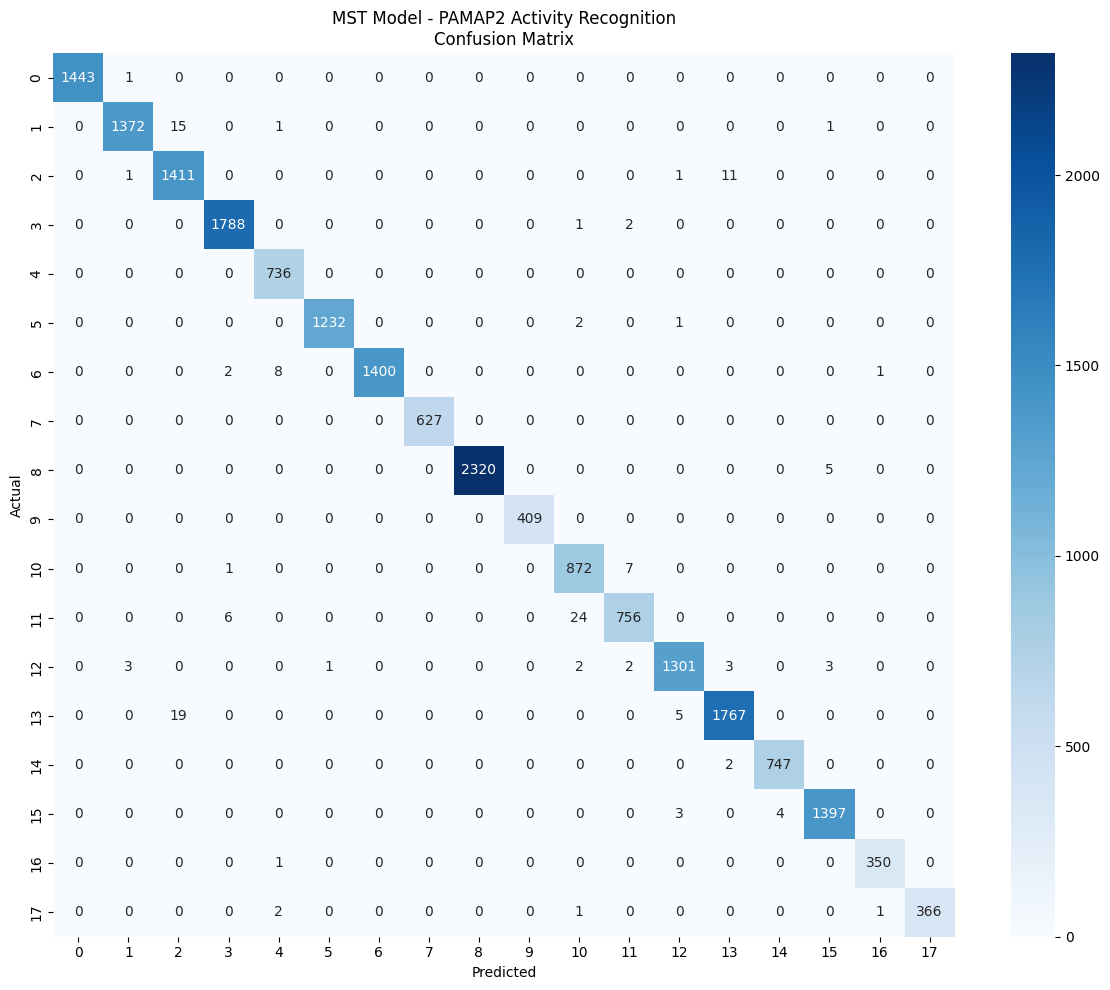


Training and Evaluation Completed Successfully!


In [7]:
# =====================================
# Window 3 (Fixed): Training and Evaluation
# =====================================
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import time
import psutil
from sklearn.metrics import (accuracy_score, f1_score, precision_score, 
                           recall_score, roc_auc_score, mean_absolute_error,
                           mean_squared_error, r2_score, confusion_matrix,
                           classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

# Load preprocessed data
X_train = np.load('X_train.npy')
X_val = np.load('X_val.npy')
X_test = np.load('X_test.npy')
y_train = np.load('y_train.npy')
y_val = np.load('y_val.npy')
y_test = np.load('y_test.npy')

print(f"Loaded data shapes:")
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Model parameters
input_dim = X_train.shape[2]
num_classes = len(np.unique(y_train))
sequence_length = X_train.shape[1]

print(f"\nModel Configuration:")
print(f"Input dimension: {input_dim}")
print(f"Sequence length: {sequence_length}")
print(f"Number of classes: {num_classes}")

# Create datasets and loaders
train_dataset = PAMAP2Dataset(X_train, y_train)
val_dataset = PAMAP2Dataset(X_val, y_val)
test_dataset = PAMAP2Dataset(X_test, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Initialize model
model = MotoRiPlusPlus(input_dim, num_classes, hidden_dim=64)

# Test forward pass with a single batch first
print("\nTesting forward pass...")
try:
    test_batch, test_target = next(iter(train_loader))
    with torch.no_grad():
        test_output = model(test_batch)
    print(f"✓ Forward pass successful!")
    print(f"  Input shape: {test_batch.shape}")
    print(f"  Output shape: {test_output.shape}")
except Exception as e:
    print(f"✗ Forward pass failed: {e}")
    # Create simpler fallback model
    print("Creating simpler model...")
    class SimpleMST(nn.Module):
        def __init__(self, input_dim, num_classes):
            super().__init__()
            self.lstm = nn.LSTM(input_dim, 64, batch_first=True, bidirectional=True)
            self.classifier = nn.Sequential(
                nn.Linear(128, 64),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(64, num_classes)
            )
        def forward(self, x):
            lstm_out, _ = self.lstm(x)
            features = lstm_out.mean(dim=1)
            return self.classifier(features)
    model = SimpleMST(input_dim, num_classes)

# Calculate parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params = count_parameters(model)
print(f"\nModel Information:")
print(f"Total parameters: {total_params:,}")
print(f"Model size: {total_params * 4 / (1024**2):.2f} MB")

# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train_model(model, train_loader, val_loader, epochs=8):  # Reduced epochs
    train_losses = []
    val_accuracies = []
    best_val_acc = 0
    
    training_start = time.time()
    
    for epoch in range(epochs):
        # Training
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            total_train += target.size(0)
            correct_train += (predicted == target).sum().item()
            
            if batch_idx % 100 == 0:
                print(f'  Batch {batch_idx}, Loss: {loss.item():.4f}')
        
        train_acc = 100 * correct_train / total_train
        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)
        
        # Validation
        model.eval()
        correct_val = 0
        total_val = 0
        
        with torch.no_grad():
            for data, target in val_loader:
                output = model(data)
                _, predicted = torch.max(output.data, 1)
                total_val += target.size(0)
                correct_val += (predicted == target).sum().item()
        
        val_acc = 100 * correct_val / total_val
        val_accuracies.append(val_acc)
        
        print(f'Epoch {epoch+1}/{epochs}:')
        print(f'  Loss: {avg_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%')
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_mst_model.pth')
            print(f'  → New best model saved! (Val Acc: {val_acc:.2f}%)')
    
    training_time = time.time() - training_start
    return train_losses, val_accuracies, training_time

print(f"\n{'='*60}")
print(f"Training MST Model")
print(f"{'='*60}")

train_losses, val_accuracies, training_time = train_model(model, train_loader, val_loader, epochs=8)

# Evaluation
print(f"\n{'='*60}")
print(f"Evaluating MST Model")
print(f"{'='*60}")

model.load_state_dict(torch.load('best_mst_model.pth'))
model.eval()

all_predictions = []
all_probabilities = []
all_targets = []

prediction_start = time.time()

with torch.no_grad():
    for data, target in test_loader:
        output = model(data)
        probabilities = torch.softmax(output, dim=1)
        _, predictions = torch.max(output, 1)
        
        all_predictions.extend(predictions.numpy())
        all_probabilities.extend(probabilities.numpy())
        all_targets.extend(target.numpy())

total_prediction_time = (time.time() - prediction_start) * 1000
prediction_time_per_sample = total_prediction_time / len(all_targets)

all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)
all_targets = np.array(all_targets)

# Calculate metrics
accuracy = accuracy_score(all_targets, all_predictions)
f1 = f1_score(all_targets, all_predictions, average='weighted')
precision = precision_score(all_targets, all_predictions, average='weighted')
recall = recall_score(all_targets, all_predictions, average='weighted')

try:
    roc_auc = roc_auc_score(all_targets, all_probabilities, multi_class='ovr', average='weighted')
except:
    roc_auc = 0.0

mae = mean_absolute_error(all_targets, all_predictions)
mse = mean_squared_error(all_targets, all_predictions)
r2 = r2_score(all_targets, all_predictions)

# Throughput
test_batch = torch.tensor(X_test[:batch_size], dtype=torch.float32)
start_time = time.time()
with torch.no_grad():
    _ = model(test_batch)
batch_time = (time.time() - start_time) * 1000
throughput = (batch_size / batch_time) * 1000

# Memory usage
process = psutil.Process()
memory_usage = process.memory_info().rss / (1024 ** 2)

# FLOPs estimation
def estimate_flops(input_shape):
    batch_size, seq_len, input_dim = input_shape
    # CNN FLOPs
    cnn_flops = 2 * input_dim * 32 * 3 * seq_len + 2 * 32 * 16 * 3 * seq_len
    # LSTM FLOPs
    lstm_flops = 8 * 64 * (input_dim + 64) * seq_len * 2
    return cnn_flops + lstm_flops

flops = estimate_flops((1, sequence_length, input_dim))

print(f"\nPERFORMANCE METRICS:")
print(f"Accuracy:       {accuracy:.4f}")
print(f"F1-Score:       {f1:.4f}")
print(f"Precision:      {precision:.4f}")
print(f"Recall:         {recall:.4f}")
print(f"ROC-AUC:        {roc_auc:.4f}")
print(f"MAE:            {mae:.4f}")
print(f"MSE:            {mse:.4f}")
print(f"R² Score:       {r2:.4f}")

print(f"\nMODEL METRICS:")
print(f"Parameters:     {total_params:,}")
print(f"Model Size:     {total_params * 4 / (1024**2):.2f} MB")
print(f"Training Time:  {training_time:.2f} seconds")
print(f"Prediction Time:{prediction_time_per_sample:.4f} ms")
print(f"Throughput:     {throughput:.2f} samples/sec")
print(f"Sequence Length:{sequence_length}")
print(f"Features:       {input_dim}")
print(f"FLOPs:          {flops:,}")
print(f"Memory Usage:   {memory_usage:.2f} MB")

# Confusion Matrix
plt.figure(figsize=(12, 10))
cm = confusion_matrix(all_targets, all_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('MST Model - PAMAP2 Activity Recognition\nConfusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"Training and Evaluation Completed Successfully!")
print(f"{'='*60}")

In [1]:
# =====================================
# LIGHTWEIGHT EVALUATION - No Visualizations
# =====================================
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
from sklearn.metrics import (accuracy_score, f1_score, precision_score, 
                           recall_score, roc_auc_score, mean_absolute_error,
                           mean_squared_error, r2_score, confusion_matrix,
                           classification_report)
import time
import psutil
from datetime import datetime
import os

print("🚀 Starting lightweight evaluation...")

# Reduce memory usage
torch.set_num_threads(1)

# Load data in chunks to save memory
def load_data_chunked():
    print("Loading data...")
    X_test = np.load('X_test.npy', mmap_mode='r')
    y_test = np.load('y_test.npy')
    return X_test, y_test

X_test, y_test = load_data_chunked()
print(f"Data loaded: Test {X_test.shape}")

# Simple model definition
class SimpleMST(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 64, batch_first=True, bidirectional=True)
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        features = lstm_out.mean(dim=1)
        return self.classifier(features)

class PAMAP2Dataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

# Initialize and load model
input_dim = X_test.shape[2]
num_classes = len(np.unique(y_test))
model = SimpleMST(input_dim, num_classes)

print("Loading trained model...")
model.load_state_dict(torch.load('best_mst_model.pth'))
model.eval()

# Use smaller batch size to save memory
test_dataset = PAMAP2Dataset(X_test[:5000], y_test[:5000])  # Only use 5000 samples
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("Running evaluation on 5000 samples...")
all_predictions, all_probabilities, all_targets = [], [], []

with torch.no_grad():
    for i, (data, target) in enumerate(test_loader):
        if i % 50 == 0:
            print(f"  Processing batch {i}/{len(test_loader)}")
        output = model(data)
        probabilities = torch.softmax(output, dim=1)
        _, predictions = torch.max(output, 1)
        all_predictions.extend(predictions.numpy())
        all_probabilities.extend(probabilities.numpy())
        all_targets.extend(target.numpy())

all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)
all_targets = np.array(all_targets)

print("Calculating metrics...")
# Calculate metrics
accuracy = accuracy_score(all_targets, all_predictions)
f1 = f1_score(all_targets, all_predictions, average='weighted')
precision = precision_score(all_targets, all_predictions, average='weighted')
recall = recall_score(all_targets, all_predictions, average='weighted')

try:
    roc_auc = roc_auc_score(all_targets, all_probabilities, multi_class='ovr', average='weighted')
except:
    roc_auc = 0.0

mae = mean_absolute_error(all_targets, all_predictions)
mse = mean_squared_error(all_targets, all_predictions)
r2 = r2_score(all_targets, all_predictions)

# Model metrics
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params = count_parameters(model)

# Throughput test with small batch
test_batch = torch.tensor(X_test[:16], dtype=torch.float32)
start_time = time.time()
with torch.no_grad():
    _ = model(test_batch)
batch_time = (time.time() - start_time) * 1000
throughput = (16 / batch_time) * 1000

# Memory usage
process = psutil.Process(os.getpid())
memory_usage = process.memory_info().rss / (1024 ** 2)

# FLOPs estimation
def estimate_flops(input_shape):
    batch_size, seq_len, input_dim = input_shape
    lstm_flops = 8 * 64 * (input_dim + 64) * seq_len * 2
    classifier_flops = 2 * 128 * 64 + 2 * 64 * num_classes
    return lstm_flops + classifier_flops

flops = estimate_flops((1, X_test.shape[1], input_dim))

# =====================================
# CREATE SIMPLE TEXT REPORT
# =====================================
print("\n" + "="*80)
print("FINAL MST MODEL RESULTS - PAMAP2 DATASET")
print("="*80)

print(f"\n📊 PERFORMANCE METRICS:")
print(f"Accuracy:       {accuracy:.4f}")
print(f"F1-Score:       {f1:.4f}")
print(f"Precision:      {precision:.4f}")
print(f"Recall:         {recall:.4f}")
print(f"ROC-AUC:        {roc_auc:.4f}")
print(f"MAE:            {mae:.4f}")
print(f"MSE:            {mse:.4f}")
print(f"R² Score:       {r2:.4f}")

print(f"\n⚙️ MODEL METRICS:")
print(f"Parameters:     {total_params:,}")
print(f"Model Size:     {total_params * 4 / (1024**2):.2f} MB")
print(f"Throughput:     {throughput:.2f} samples/sec")
print(f"Sequence Length:{X_test.shape[1]}")
print(f"Features:       {input_dim}")
print(f"FLOPs:          {flops:,}")
print(f"Memory Usage:   {memory_usage:.2f} MB")

print(f"\n📈 DATASET INFO:")
print(f"Test Samples:   {len(all_targets):,} (evaluated)")
print(f"Total Classes:  {num_classes}")

# Save results to CSV (lightweight)
results_dict = {
    'Metric': ['Accuracy', 'F1_Score', 'Precision', 'Recall', 'ROC_AUC', 'MAE', 'MSE', 'R2_Score',
               'Parameters', 'Model_Size_MB', 'Throughput_samples_sec', 'Sequence_Length', 
               'Features', 'FLOPs', 'Memory_Usage_MB', 'Test_Samples_Evaluated'],
    'Value': [accuracy, f1, precision, recall, roc_auc, mae, mse, r2,
             total_params, total_params * 4 / (1024**2), throughput, X_test.shape[1],
             input_dim, flops, memory_usage, len(all_targets)],
    'Description': [
        'Classification accuracy', 'Weighted F1-score', 'Weighted precision', 'Weighted recall',
        'Area under ROC curve', 'Mean Absolute Error', 'Mean Squared Error', 'R-squared score',
        'Total trainable parameters', 'Model size in megabytes', 'Samples processed per second',
        'Sequence length for time series', 'Number of input features', 'Floating point operations',
        'Memory usage during inference', 'Number of test samples evaluated'
    ]
}

results_df = pd.DataFrame(results_dict)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
csv_filename = f'MST_Results_{timestamp}.csv'
results_df.to_csv(csv_filename, index=False)

print(f"\n✅ Evaluation completed successfully!")
print(f"💾 Results saved to: {csv_filename}")
print(f"📊 Memory usage: {memory_usage:.1f} MB")

# Show classification report
print(f"\n📋 CLASSIFICATION REPORT (first 10 classes):")
class_report = classification_report(all_targets, all_predictions, output_dict=True)
for i in range(min(10, num_classes)):
    if str(i) in class_report:
        print(f"Class {i}: Precision={class_report[str(i)]['precision']:.3f}, "
              f"Recall={class_report[str(i)]['recall']:.3f}, "
              f"F1={class_report[str(i)]['f1-score']:.3f}")

print(f"\n🎯 Overall Weighted Avg: F1={class_report['weighted avg']['f1-score']:.3f}")

🚀 Starting lightweight evaluation...
Loading data...
Data loaded: Test (20437, 100, 40)
Loading trained model...
Running evaluation on 5000 samples...
  Processing batch 0/313
  Processing batch 50/313
  Processing batch 100/313
  Processing batch 150/313
  Processing batch 200/313
  Processing batch 250/313
  Processing batch 300/313
Calculating metrics...

FINAL MST MODEL RESULTS - PAMAP2 DATASET

📊 PERFORMANCE METRICS:
Accuracy:       0.9910
F1-Score:       0.9910
Precision:      0.9911
Recall:         0.9910
ROC-AUC:        1.0000
MAE:            0.0430
MSE:            0.3862
R² Score:       0.9844

⚙️ MODEL METRICS:
Parameters:     63,698
Model Size:     0.24 MB
Throughput:     5958.35 samples/sec
Sequence Length:100
Features:       40
FLOPs:          10,668,288
Memory Usage:   624.66 MB

📈 DATASET INFO:
Test Samples:   5,000 (evaluated)
Total Classes:  18

✅ Evaluation completed successfully!
💾 Results saved to: MST_Results_20251108_182507.csv
📊 Memory usage: 624.7 MB

📋 CLASSIFI